# Camera Test Publisher - Integration Test

Subscribe to the camera test topics and capture 5 frames with camera intrinsics.

Prerequisites:
- Build the workspace: `colcon build --packages-select camera_test_publisher`
- Source the workspace: `source install/setup.bash`
- Launch the node: `ros2 launch camera_test_publisher camera_test_publisher.launch.py`

In [1]:
import os

os.environ['CYCLONEDDS_URI'] = 'file:///tmp/cyclonedds_eth1.xml'

import threading
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
from cv_bridge import CvBridge

import rclpy
from rclpy.node import Node
from rclpy.qos import QoSProfile, ReliabilityPolicy
from sensor_msgs.msg import CameraInfo, Image

In [2]:
CAPTURE_COUNT = 5
IMAGE_TOPIC = '/camera/test'
CAMERA_INFO_TOPIC = '/camera/test/camera_info'

collected_frames = []
collected_camera_info = []
bridge = CvBridge()
qos = QoSProfile(depth=10, reliability=ReliabilityPolicy.RELIABLE)


class FrameCollector(Node):
    def __init__(self):
        super().__init__('frame_collector')
        self.image_sub = self.create_subscription(
            Image, IMAGE_TOPIC, self._image_callback, qos
        )
        self.info_sub = self.create_subscription(
            CameraInfo, CAMERA_INFO_TOPIC, self._info_callback, qos
        )
        self._latest_info = None

    def _image_callback(self, msg: Image):
        if len(collected_frames) >= CAPTURE_COUNT:
            return
        frame = bridge.imgmsg_to_cv2(msg, desired_encoding='bgr8')
        collected_frames.append(frame)
        if self._latest_info is not None:
            collected_camera_info.append(self._latest_info)
        else:
            collected_camera_info.append(None)
        self.get_logger().info(
            f'Captured frame {len(collected_frames)}/{CAPTURE_COUNT} '
            f'({msg.width}x{msg.height})'
        )

    def _info_callback(self, msg: CameraInfo):
        self._latest_info = msg
        for i, info in enumerate(collected_camera_info):
            if info is None:
                collected_camera_info[i] = msg


if not rclpy.ok():
    rclpy.init()

node = FrameCollector()

def _spin():
    while rclpy.ok():
        rclpy.spin_once(node, timeout_sec=0.1)

spin_thread = threading.Thread(target=_spin, daemon=True)
spin_thread.start()
print(f'Collecting {CAPTURE_COUNT} frames from {IMAGE_TOPIC} ...')

In [3]:
timeout = 15
start = time.time()
while len(collected_frames) < CAPTURE_COUNT and (time.time() - start) < timeout:
    time.sleep(0.5)

if len(collected_frames) < CAPTURE_COUNT:
    print(f'Timeout: only captured {len(collected_frames)}/{CAPTURE_COUNT} frames')
    print(f'Make sure camera_test_publisher is running with: export CYCLONEDDS_URI=\'file:///tmp/cyclonedds_eth1.xml\'')
else:
    print(f'Successfully captured {len(collected_frames)} frames')

Successfully captured 5 frames


[INFO] [1776486489.090429184] [frame_collector]: Captured frame 1/5 (640x480)
[INFO] [1776486489.113942553] [frame_collector]: Captured frame 2/5 (640x480)
[INFO] [1776486489.138086935] [frame_collector]: Captured frame 3/5 (640x480)
[INFO] [1776486489.257181347] [frame_collector]: Captured frame 4/5 (640x480)
[INFO] [1776486489.267431496] [frame_collector]: Captured frame 5/5 (640x480)


## Display captured frames

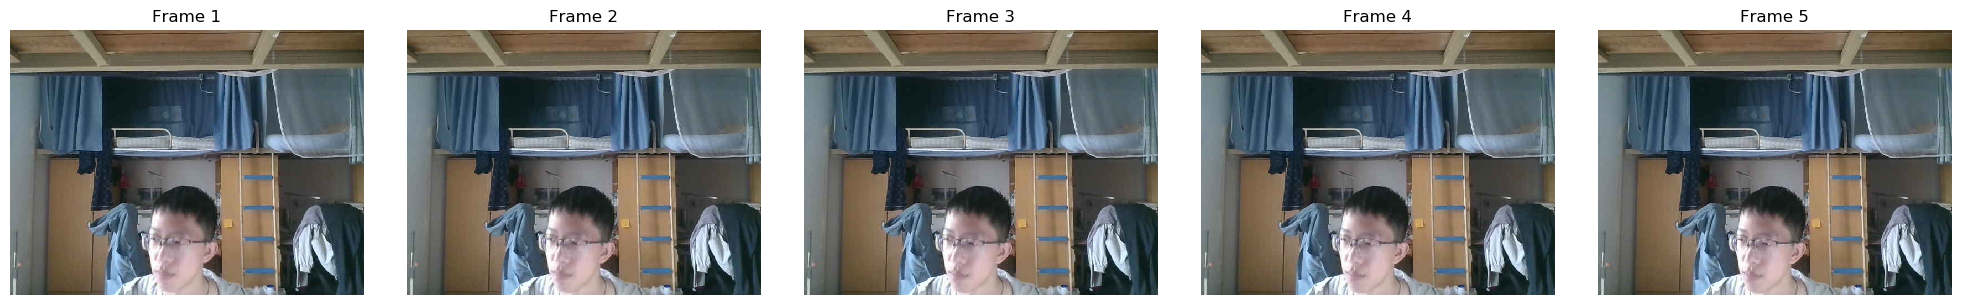

In [4]:
if collected_frames:
    n = len(collected_frames)
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    for idx, frame in enumerate(collected_frames):
        r, c = divmod(idx, cols)
        ax = axes[r][c] if rows > 1 else axes[c]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax.imshow(rgb)
        ax.set_title(f'Frame {idx + 1}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No frames captured.')

## Camera intrinsics

In [5]:
if collected_camera_info and collected_camera_info[0] is not None:
    info = collected_camera_info[0]
    K = np.array(info.k).reshape(3, 3)
    D = np.array(info.d)
    P = np.array(info.p).reshape(3, 4)
    R = np.array(info.r).reshape(3, 3)

    print(f'Frame ID:   {info.header.frame_id}')
    print(f'Resolution: {info.width} x {info.height}')
    print(f'Distortion: {info.distortion_model}')
    print(f'D coeffs:   {D}')
    print(f'\nIntrinsic matrix K (3x3):')
    print(np.array2string(K, precision=2, suppress_small=True))
    print(f'\nProjection matrix P (3x4):')
    print(np.array2string(P, precision=2, suppress_small=True))
    print(f'\nRectification matrix R (3x3):')
    print(np.array2string(R, precision=2, suppress_small=True))
else:
    print('No camera info received.')

Frame ID:   camera_test_frame
Resolution: 640 x 480
Distortion: plumb_bob
D coeffs:   [0. 0. 0. 0. 0.]

Intrinsic matrix K (3x3):
[[640.   0. 320.]
 [  0. 640. 240.]
 [  0.   0.   1.]]

Projection matrix P (3x4):
[[640.   0. 320.   0.]
 [  0. 640. 240.   0.]
 [  0.   0.   1.   0.]]

Rectification matrix R (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## Cleanup

In [6]:
try:
    node.destroy_node()
except NameError:
    pass
if rclpy.ok():
    rclpy.shutdown()
print('Cleanup done.')

Cleanup done.
